<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/scenario4_exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HARISH MK
24BAD031
   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0

Missing values:
 Age             0
Cholesterol     0
MaxHeartRate    0
RestingBP       0
HeartDisease    0
dtype: int64

HeartDisease distribution:
HeartDisease
1    83
0    37
Name: count, dtype: int64
MODEL PERFORMANCE COMPARISON
Model                   Train Acc   Test Acc    CV Mean   CV Std
Logistic Regression        0.7396     0.7083     0.7084   0.0528
SVM                        0.7708     0.7917     0.6253   0.0755
Decision Tree              0.8958     0.6250     0.7179   0.0737
Stacking Ensemble          0.8750     0.7500     0.6979   0.0204

Stacking Ensemble Report
              precision    recall  f1-score

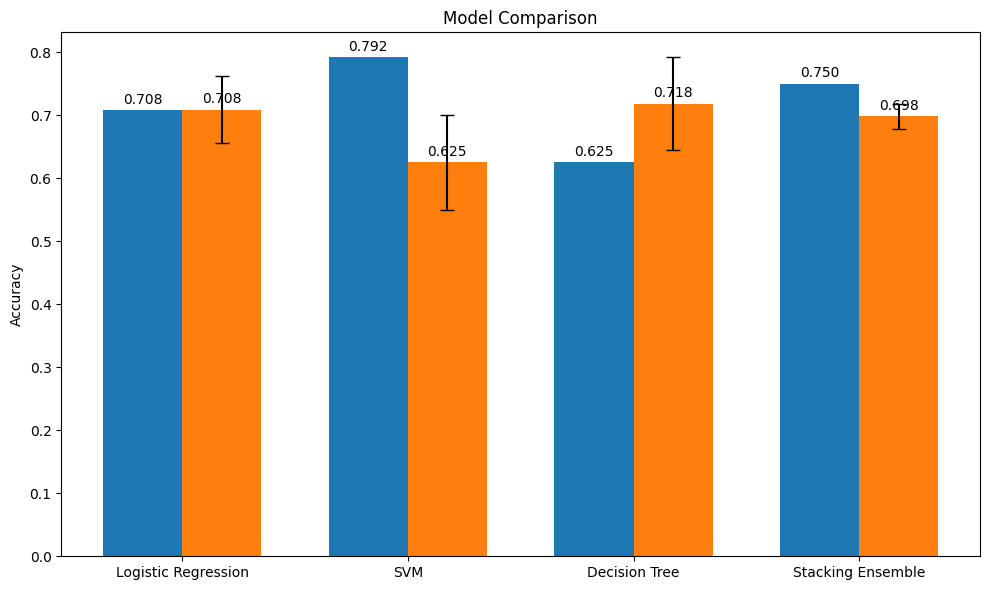

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("HARISH MK")
print("24BAD031")

df = pd.read_csv("heart_stacking.csv")

print(df.head())
print("\nMissing values:\n", df.isnull().sum())
print(f"\nHeartDisease distribution:\n{df['HeartDisease'].value_counts()}")

feature_names = ['Cholesterol', 'MaxHeartRate', 'Age']
X = df[feature_names]
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
svm = SVC(kernel='rbf', probability=True, random_state=42)
dt = DecisionTreeClassifier(max_depth=4, random_state=42)

meta = LogisticRegression(max_iter=1000, random_state=42)

stack = StackingClassifier(
    estimators=[
        ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
        ('SVM', SVC(kernel='rbf', probability=True, random_state=42)),
        ('Decision Tree', DecisionTreeClassifier(max_depth=4, random_state=42)),
    ],
    final_estimator=meta,
    cv=5,
    passthrough=False
)

models = {
    'Logistic Regression': lr,
    'SVM': svm,
    'Decision Tree': dt,
    'Stacking Ensemble': stack,
}

results = {}

print("MODEL PERFORMANCE COMPARISON")
print(f"{'Model':<22}  {'Train Acc':>9}  {'Test Acc':>9}  {'CV Mean':>9}  {'CV Std':>7}")

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    tr_acc = accuracy_score(y_train, model.predict(X_train_sc))
    te_acc = accuracy_score(y_test, y_pred)
    cv = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
    results[name] = {'train': tr_acc, 'test': te_acc,
                     'cv_mean': cv.mean(), 'cv_std': cv.std(),
                     'y_pred': y_pred}
    print(f"{name:<22}  {tr_acc:>9.4f}  {te_acc:>9.4f}  {cv.mean():>9.4f}  {cv.std():>7.4f}")

print("\nStacking Ensemble Report")
print(classification_report(y_test, results['Stacking Ensemble']['y_pred'],
                           target_names=["No Disease", "Disease"]))
print(confusion_matrix(y_test, results['Stacking Ensemble']['y_pred']))

models_list = ['Logistic Regression', 'SVM', 'Decision Tree', 'Stacking Ensemble']

test_acc = [results[m]['test'] for m in models_list]
cv_acc = [results[m]['cv_mean'] for m in models_list]
cv_std = [results[m]['cv_std'] for m in models_list]

x = np.arange(len(models_list))
bar_width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - bar_width/2, test_acc, width=bar_width)
plt.bar(x + bar_width/2, cv_acc, width=bar_width, yerr=cv_std, capsize=5)

plt.xticks(x, models_list)
plt.ylabel("Accuracy")
plt.title("Model Comparison")

for i in range(len(models_list)):
    plt.text(x[i] - bar_width/2, test_acc[i] + 0.01, f"{test_acc[i]:.3f}", ha='center')
    plt.text(x[i] + bar_width/2, cv_acc[i] + 0.01, f"{cv_acc[i]:.3f}", ha='center')

plt.tight_layout()
plt.show()